In [1]:
import numpy as np

def levy_matrix(N, mu, diag_mode="zero", sign_mode="positive", rng=None):
    """
    N*N Levy Matrix Construction (elements decay as  H^{-(1+mu)})
    
    diag_mode:
      - "zero": all zero on the diagonal
      - "same": elements on the diagonal follow power-law distribution
    """
    if rng is None:
        rng = np.random.default_rng()
    
    H = np.zeros((N, N), dtype=float)
    
    idx_i, idx_j = np.triu_indices(N, k=1) # 'triu' for 'triangular upper', 'k' is the diagonal offset
    # eg. idx_i = array([0,0,0,1,1,2]) and idx_j = array([1,2,3,2,3,3])
    
    M = idx_i.size # M = N(N-1)/2
    
    H0 = N ** (-1.0 / mu) # scaling of matrix: H0 ~ N^{-1/mu}
    abs_vals = H0 * rng.pareto(mu, size=M) # pareto function generates distribution: P(x) = mu*(1+x)^{-(1+mu)}
    
    # Sign
    if sign_mode == "random":
        signs = rng.choice([-1.0, 1.0], size=M)
        vals = signs * abs_vals
    else:
        vals = abs_vals
    
    H[idx_i, idx_j] = vals
    H[idx_j, idx_i] = vals
    
    # Diagonal Elements
    if diag_mode == "same":
        abs_diag = H0 * (rng.pareto(mu, size=N) + 1.0)
        signs_diag = rng.choice([-1.0, 1.0], size=N)
        H[np.diag_indices(N)] = signs_diag * abs_diag
    elif diag_mode == "zero":
        pass
    elif diag_mode == "one":
        pass
    else:
        raise ValueError("diag_mode must be 'zero' or 'same'")
    
    return H


In [2]:
def sample_eigenvalues(N, mu, n_mats=20, diag_mode="zero", rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    eigs_all = []
    for _ in range(n_mats):
        H = levy_matrix(N, mu, diag_mode=diag_mode, sign_mode="positive", rng=rng)
        # 'eigvalsh' for symmetric matrix
        eigs = np.linalg.eigvalsh(H)
        eigs_all.append(eigs)
    return np.concatenate(eigs_all)



N = 1500
mu = 1.5
eigs = sample_eigenvalues(N, mu, n_mats=100)
abs_eigs = np.abs(eigs)

print("eigs.shape:", eigs.shape)


eigs.shape: (150000,)


In [3]:
import numpy as np

def fit_power_law_tail(data, xmin, n_bins=100):
    """
    p(x) ~ x^(-alpha)
    """
    data_tail = data[data > xmin]
    if data_tail.size < 100:
        raise RuntimeError("Sample Number is not enough for fitting.")
    
    counts, bin_edges = np.histogram(data_tail, bins=n_bins, density=True)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    mask = (counts > 0) & (centers > 0)
    counts = counts[mask]
    centers = centers[mask]
    
    log_x = np.log(centers)
    log_p = np.log(counts)
    
    # log p = -alpha * log x + c
    slope, intercept = np.polyfit(log_x, log_p, 1)
    alpha = -slope
    return alpha, intercept

xmin = 2.0
alpha_hat, _ = fit_power_law_tail(abs_eigs, xmin=xmin)
print("DOS alpha =", alpha_hat)
print("alpha_theory = 1 + mu =", 1 + mu)


DOS alpha = 1.802496076121632
alpha_theory = 1 + mu = 2.5


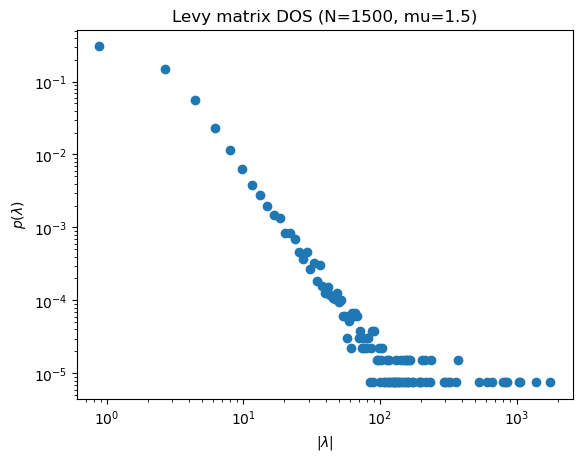

In [4]:
import matplotlib.pyplot as plt

counts, bin_edges = np.histogram(abs_eigs, bins=1000, density=True)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.loglog(centers[counts>0], counts[counts>0], marker='o', linestyle='none')
plt.xlabel(r'$|\lambda|$')
plt.ylabel(r'$p(\lambda)$')
plt.title(fr'Levy matrix DOS (N={N}, mu={mu})')
plt.show()
